<a href="https://colab.research.google.com/github/NickBoivinSlu/ores5160-2026/blob/main/ORES_5160_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#ORES 5160: Final Assignment
##Topic: Comparing Medicare and Medicaid Hospitals in the US and the Number of Patients Discharged


---
Nick Boivin


---




#Part 1: Data Ingestion & File Parsing

###1. Importing the CSV file | Medicare Hospitals Databse

[DATA.GOV: Inpatient Prospective Payment System (IPPS) Provider Summary for the Top 100 Diagnosis-Related Groups (DRG)](https://catalog.data.gov/dataset/inpatient-prospective-payment-system-ipps-provider-summary-for-the-top-100-diagnosis-relat?from_hint=eyJxIjoibWVkaWNhcmUiLCJyZXN1bHRzIjoiNDAiLCJzb3J0IjoicG9wdWxhcml0eSIsIm9yZ19zbHVnIjoiaGhzIn0%3D)

[Data Dictionary](https://data.cms.gov/resources/medicare-inpatient-hospitals-by-provider-and-service-data-dictionary-0)

In [367]:
#------------------
#Preview CSV
#-----------------
import pandas as pd
df = pd.read_csv('/content/Medicare_IP_Hospitals_by_Provider_and_Service_2024.csv')
df.head(10)

,Rndrng_Prvdr_CCN,Rndrng_Prvdr_Org_Name,Rndrng_Prvdr_City,Rndrng_Prvdr_St,Rndrng_Prvdr_State_FIPS,Rndrng_Prvdr_Zip5,Rndrng_Prvdr_State_Abrvtn,Rndrng_Prvdr_RUCA,Rndrng_Prvdr_RUCA_Desc,DRG_Cd,DRG_Desc,Tot_Dschrgs,Avg_Submtd_Cvrd_Chrg,Avg_Tot_Pymt_Amt,Avg_Mdcr_Pymt_Amt
0,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.0,Metropolitan area high commuting: primary flow...,3,ECMO OR TRACHEOSTOMY WITH MV >96 HOURS OR PRIN...,11,738478.636360,103236.272730,91218.181818
1,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.0,Metropolitan area high commuting: primary flow...,23,CRANIOTOMY WITH MAJOR DEVICE IMPLANT OR ACUTE ...,23,173562.086960,40220.217391,37634.565217
2,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.0,Metropolitan area high commuting: primary flow...,24,CRANIOTOMY WITH MAJOR DEVICE IMPLANT OR ACUTE ...,13,95613.307692,27305.461538,25644.307692
3,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.0,Metropolitan area high commuting: primary flow...,25,CRANIOTOMY AND ENDOVASCULAR INTRACRANIAL PROCE...,22,182831.409090,31420.954545,23270.863636
4,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.0,Metropolitan area high commuting: primary flow...,38,EXTRACRANIAL PROCEDURES WITH CC,27,111318.555560,12183.925926,10532.222222
5,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.0,Metropolitan area high commuting: primary flow...,39,EXTRACRANIAL PROCEDURES WITHOUT CC/MCC,47,90166.212766,9712.510638,7136.319149
6,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.0,Metropolitan area high commuting: primary flow...,56,DEGENERATIVE NERVOUS SYSTEM DISORDERS WITH MCC,13,65932.000000,16949.000000,14845.769231
7,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.0,Metropolitan area high commuting: primary flow...,57,DEGENERATIVE NERVOUS SYSTEM DISORDERS WITHOUT MCC,20,26026.500000,10431.650000,8639.300000
8,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.0,Metropolitan area high commuting: primary flow...,64,INTRACRANIAL HEMORRHAGE OR CEREBRAL INFARCTION...,74,71396.337838,14841.040541,12331.918919
9,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.0,Metropolitan area high commuting: primary flow...,65,INTRACRANIAL HEMORRHAGE OR CEREBRAL INFARCTION...,62,40065.596774,8402.016129,6009.790323


##2. Importing the Json File - Medicaid Hospitals Database

[DATA.GOV: Hospital Provider Cost Report (API)
](https://catalog.data.gov/dataset/hospital-provider-cost-report?from_hint=eyJxIjoibWVkaWNhcmUiLCJyZXN1bHRzIjoiNDAiLCJzb3J0IjoicG9wdWxhcml0eSIsIm9yZ19zbHVnIjoiaGhzIn0%3D)

No Data Dictionary Found


In [368]:
#-----------------
#Import the JSON File
#-----------------
import requests

# Replace this with the actual API endpoint URL found after clicking 'Visit Page'
api_url = "http://data.cms.gov/data-api/v1/dataset/18a16b22-890c-4320-b5fc-cd2ab0cd1238/data"

# Send a GET request to the API
response = requests.get(api_url)

# Check if the request was successful (Status Code 200)
if response.status_code == 200:
    #Load directly into a Pandas DataFrame for analysis
    data = response.json()
    hospital_financials = pd.DataFrame(data)
    display(hospital_financials.head(5))
else:
    print(f"Failed to fetch data. Status code: {response.status_code}")


filename = 'Hospital_financials.csv'
medicaid_hospitals = hospital_financials.to_csv(filename, index = False)

medicaid_hospitals = pd.read_csv('/content/Hospital_financials.csv')

,rpt_rec_num,Provider CCN,Hospital Name,Street Address,City,State Code,Zip Code,County,Medicare CBSA Number,Rural Versus Urban,...,Net Income from Service to Patients,Total Other Income,Total Income,Total Other Expenses,Net Income,Cost To Charge Ratio,Net Revenue from Medicaid,Medicaid Charges,Net Revenue from Stand-Alone CHIP,Stand-Alone CHIP Charges
0,601721,341317,PIONEER HLTH SERV OF STOKES CNTY,1570 NC & 89 HWY,DANBURY,NC,27016,STOKES,49180,U,...,-901933,1542201,640268,622592,17676,1.154767,578366,801800,159516,702117
1,611885,364045,POMEGRANATE HEALTH,765 PIERCE DR,COLUMBUS,OH,43223,,,NA,...,,,,,,,,,,
2,618974,660001,COMMONWEALTH HEALTH CENTER,LOWER NAVY HILL RD,SAIPAN,MP,96950,CNMI,99966,R,...,-47712134,,-47712134,,-47712134,1728.42872,,,,
3,621121,421302,FAIRFIELD MEMORIAL HOSPITAL,102 US HWY 31 BYPASS NORTH,WINSBORO,SC,29180-0620,FAIRFIELD,17900,U,...,-2290872,3190896,900024,2293225,-1393201,0.659065,105832,405787,,
4,621140,511306,ROANE GENERAL HOSPITAL,200 HOSPITAL DRIVE,SPENCER,WV,25276-1060,ROANE,99951,R,...,-1090128,3147409,2057281,,2057281,0.406979,10651691,23783068,202435,395744


#Part 2A. Medicare Database (CSV) Clean, transform, and validate the data

In [369]:
#------------------
#Look at the column names
#-----------------
df.columns.unique()

Index(['Rndrng_Prvdr_CCN', 'Rndrng_Prvdr_Org_Name', 'Rndrng_Prvdr_City',
       'Rndrng_Prvdr_St', 'Rndrng_Prvdr_State_FIPS', 'Rndrng_Prvdr_Zip5',
       'Rndrng_Prvdr_State_Abrvtn', 'Rndrng_Prvdr_RUCA',
       'Rndrng_Prvdr_RUCA_Desc', 'DRG_Cd', 'DRG_Desc', 'Tot_Dschrgs',
       'Avg_Submtd_Cvrd_Chrg', 'Avg_Tot_Pymt_Amt', 'Avg_Mdcr_Pymt_Amt'],
      dtype='object')

##Identify the column names from the data dictionary


---




**Provider Info**
---
**Rndrng_Prvdr_CCN** - (CCN) of the provider billing for inpatient hospital services.

**Rndrng_Prvdr_Org_Name** - The name of the provider.


**Rndrng_Prvdr_City** - The city in which the provider is physically located.



**Rndrng_Prvdr_St** - The street address in which the provider is physically located.


**Rndrng_Prvdr_State_FIPS** - The state FIPS code for the state in which the provider is physically located.


**Rndrng_Prvdr_Zip5** - The zip code in which the provider is physically located.



**Rndrng_Prvdr_State_Abrvtn** - The state abbreviation for the state in which the provider is physically located.

---
**Rural or Urban Location of Provider**
---
**Rndrng_Prvdr_RUCA** - The Rural-Urban Commuting Area (RUCA) code for the zip code in which the provider is physically located

**Rndrng_Prvdr_RUCA_Desc** - The description of the RUCA code. RUCA codes classify zip codes as rural/urban areas based on measures of population density, level of urbanization, and daily commuting patterns. These codes are developed by United States Department of Agriculture, Economic Research Service.

---
**Diagnosis Classifcation**
---
**DRG_Cd** - Classification system that groups similar clinical conditions (diagnoses) and the procedures furnished by the hospital during the stay.

**DRG_Desc** - Description of the classification system (DRG) that groups similar clinical conditions (diagnoses) and the procedures furnished by the hospital during the stay.

---
**Provider's Production**
---
**Tot_Dschrgs** - The number of discharges billed by all providers for inpatient hospital services.


**Avg_Submtd_Cvrd_Chrg** - The average charge of all providers' services covered by Medicare for discharges in the DRG. These will vary from hospital to hospital because of differences in hospital charge structures.

**Avg_Tot_Pymt_Amt** - The average total payments to all providers for the DRG including the MS-DRG amount, teaching, disproportionate share, capital, and outlier payments for all cases. Also included in average total payments are co-payment and deductible amounts that the patient is responsible for and any additional payments by third parties for coordination of benefits.

**Avg_Mdcr_Pymt_Amt** - The average amount that Medicare pays to the provider for Medicare's share of the MS-DRG. Medicare payment amounts include the MS-DRG amount, teaching, disproportionate share, capital, and outlier payments for all cases. Medicare payments DO NOT include beneficiary co-payments and deductible amounts nor any additional payments from third parties for coordination of benefits.

##Cleaning


---


Analyze the datatypes

check for  missing values

clean up the columns

Add New column labeling all hospitals as medicare





In [370]:
#------------------
#Look at the column data types
#-----------------
df.dtypes

,0
Rndrng_Prvdr_CCN,int64
Rndrng_Prvdr_Org_Name,object
Rndrng_Prvdr_City,object
Rndrng_Prvdr_St,object
Rndrng_Prvdr_State_FIPS,int64
Rndrng_Prvdr_Zip5,int64
Rndrng_Prvdr_State_Abrvtn,object
Rndrng_Prvdr_RUCA,float64
Rndrng_Prvdr_RUCA_Desc,object
DRG_Cd,int64


In [371]:
#-----------------
#Check for Missing values
#-----------------
df.isna().sum().sum()

np.int64(0)

In [372]:
#-----------------
#Add a new column - Labeling all Providers as Medicare
#-----------------
df['Ins Accepted'] = 'Medicare'
df.head(5)

,Rndrng_Prvdr_CCN,Rndrng_Prvdr_Org_Name,Rndrng_Prvdr_City,Rndrng_Prvdr_St,Rndrng_Prvdr_State_FIPS,Rndrng_Prvdr_Zip5,Rndrng_Prvdr_State_Abrvtn,Rndrng_Prvdr_RUCA,Rndrng_Prvdr_RUCA_Desc,DRG_Cd,DRG_Desc,Tot_Dschrgs,Avg_Submtd_Cvrd_Chrg,Avg_Tot_Pymt_Amt,Avg_Mdcr_Pymt_Amt,Ins Accepted
0,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.0,Metropolitan area high commuting: primary flow...,3,ECMO OR TRACHEOSTOMY WITH MV >96 HOURS OR PRIN...,11,738478.636360,103236.272730,91218.181818,Medicare
1,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.0,Metropolitan area high commuting: primary flow...,23,CRANIOTOMY WITH MAJOR DEVICE IMPLANT OR ACUTE ...,23,173562.086960,40220.217391,37634.565217,Medicare
2,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.0,Metropolitan area high commuting: primary flow...,24,CRANIOTOMY WITH MAJOR DEVICE IMPLANT OR ACUTE ...,13,95613.307692,27305.461538,25644.307692,Medicare
3,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.0,Metropolitan area high commuting: primary flow...,25,CRANIOTOMY AND ENDOVASCULAR INTRACRANIAL PROCE...,22,182831.409090,31420.954545,23270.863636,Medicare
4,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.0,Metropolitan area high commuting: primary flow...,38,EXTRACRANIAL PROCEDURES WITH CC,27,111318.555560,12183.925926,10532.222222,Medicare


In [373]:
#-----------------
#Update the column names to be reader friendly
#-----------------

tb1 = df.rename(
    columns = { 'Rndrng_Prvdr_Org_Name': 'Hospital Name',
                'Rndrng_Prvdr_City': 'City',
                'Rndrng_Prvdr_St': 'Street',
                'Rndrng_Prvdr_State_FIPS': 'FIPS Code',
                'Rndrng_Prvdr_Zip5': 'Zip Code',
                'Rndrng_Prvdr_State_Abrvtn': 'State',
                'Rndrng_Prvdr_RUCA': 'RUCA Code',
                'Rndrng_Prvdr_RUCA_Desc': 'RUCA Classification',

                'DRG_Cd': 'Diagnosis Code',
                'DRG_Desc': 'Diagnosis Description',

                'Tot_Dschrgs': 'Total Patients Discharged',
                'Avg_Submtd_Cvrd_Chrg': 'Avg Medicare Services Billed',
                'Avg_Tot_Pymt_Amt': 'Avg Total Payment',
                'Avg_Mdcr_Pymt_Amt': 'Avg Paid by Medicare'










              })

tb1.dtypes








,0
Rndrng_Prvdr_CCN,int64
Hospital Name,object
City,object
Street,object
FIPS Code,int64
Zip Code,int64
State,object
RUCA Code,float64
RUCA Classification,object
Diagnosis Code,int64


In [374]:
#-----------------
#Drop columns we don't need
#-----------------
#Rndrng_Prvdr_CCN - CNN of provider
#'Rndrng_Prvdr_State_FIPS': 'FIPS Code'
#'Rndrng_Prvdr_RUCA': 'RUCA Code',
#'DRG_Cd': 'Diagnosis Code',
#---------------------------------
tb1 = tb1.drop(
    ['Rndrng_Prvdr_CCN', 'FIPS Code', 'RUCA Code',
    'Diagnosis Code'], axis =  1)
tb1.dtypes




,0
Hospital Name,object
City,object
Street,object
Zip Code,int64
State,object
RUCA Classification,object
Diagnosis Description,object
Total Patients Discharged,int64
Avg Medicare Services Billed,float64
Avg Total Payment,float64


#Part 2B. Medicaid Database (JSON) Clean, transform, and validate the data

##Cleaning


---





Select the columns we need add new column labeling all hospitals as medicare

check for  missing values

Analyze the datatypes

In [375]:
medicaid_hospitals.columns.unique()

Index(['rpt_rec_num', 'Provider CCN', 'Hospital Name', 'Street Address',
       'City', 'State Code', 'Zip Code', 'County', 'Medicare CBSA Number',
       'Rural Versus Urban',
       ...
       'Net Income from Service to Patients', 'Total Other Income',
       'Total Income', 'Total Other Expenses', 'Net Income',
       'Cost To Charge Ratio', 'Net Revenue from Medicaid', 'Medicaid Charges',
       'Net Revenue from Stand-Alone CHIP', 'Stand-Alone CHIP Charges'],
      dtype='object', length=117)

In [376]:
#-----------------
#Select the columns we need
#-----------------
medicaid_hospitals.columns.unique()

medicaid_hospitals = medicaid_hospitals[['Hospital Name', 'Total Discharges (V + XVIII + XIX + Unknown)', 'City', 'State Code','Street Address', 'Zip Code' ]]

#-----------------
#Add new column, labeling all hospitals as medicaid
#-----------------
medicaid_hospitals['Ins Accepted'] = 'Medicaid'
medicaid_hospitals

,Hospital Name,Total Discharges (V + XVIII + XIX + Unknown),City,State Code,Street Address,Zip Code,Ins Accepted
0,PIONEER HLTH SERV OF STOKES CNTY,52.0,DANBURY,NC,1570 NC & 89 HWY,27016,Medicaid
1,POMEGRANATE HEALTH,NaN,COLUMBUS,OH,765 PIERCE DR,43223,Medicaid
2,COMMONWEALTH HEALTH CENTER,4403.0,SAIPAN,MP,LOWER NAVY HILL RD,96950,Medicaid
3,FAIRFIELD MEMORIAL HOSPITAL,75.0,WINSBORO,SC,102 US HWY 31 BYPASS NORTH,29180-0620,Medicaid
4,ROANE GENERAL HOSPITAL,190.0,SPENCER,WV,200 HOSPITAL DRIVE,25276-1060,Medicaid
...,...,...,...,...,...,...,...
995,DALLAS COUNTY MEDICAL CENTER,166.0,FORDYCE,AR,201 NORTH CLIFTON,71742-,Medicaid
996,NINNESCAH VALLEY HEALTH SYSTEMS,282.0,KINGMAN,KS,750 AVENUE D WEST,67068,Medicaid
997,ST. ELIZABETH FLORENCE,10666.0,FLORENCE,KY,4900 HOUSTON ROAD,41042-4824,Medicaid
998,FORT WASHINGTON MEDICAL CENTER,1817.0,FORT WASHINGTON,MD,11711 LIVINGSTON ROAD,20744,Medicaid


In [377]:
#-----------------
#check for missing values
#-----------------
#hide the rows where total discharges are NA
medicaid_hospitals = medicaid_hospitals[medicaid_hospitals['Total Discharges (V + XVIII + XIX + Unknown)'].notna()]
medicaid_hospitals

,Hospital Name,Total Discharges (V + XVIII + XIX + Unknown),City,State Code,Street Address,Zip Code,Ins Accepted
0,PIONEER HLTH SERV OF STOKES CNTY,52.0,DANBURY,NC,1570 NC & 89 HWY,27016,Medicaid
2,COMMONWEALTH HEALTH CENTER,4403.0,SAIPAN,MP,LOWER NAVY HILL RD,96950,Medicaid
3,FAIRFIELD MEMORIAL HOSPITAL,75.0,WINSBORO,SC,102 US HWY 31 BYPASS NORTH,29180-0620,Medicaid
4,ROANE GENERAL HOSPITAL,190.0,SPENCER,WV,200 HOSPITAL DRIVE,25276-1060,Medicaid
5,CHOWAN HOSPITAL INC.,1389.0,EDENTON,NC,211 VIRGINIA AVENUE,27932,Medicaid
...,...,...,...,...,...,...,...
995,DALLAS COUNTY MEDICAL CENTER,166.0,FORDYCE,AR,201 NORTH CLIFTON,71742-,Medicaid
996,NINNESCAH VALLEY HEALTH SYSTEMS,282.0,KINGMAN,KS,750 AVENUE D WEST,67068,Medicaid
997,ST. ELIZABETH FLORENCE,10666.0,FLORENCE,KY,4900 HOUSTON ROAD,41042-4824,Medicaid
998,FORT WASHINGTON MEDICAL CENTER,1817.0,FORT WASHINGTON,MD,11711 LIVINGSTON ROAD,20744,Medicaid


In [378]:
#-----------------
#Analyze the datatypes
#-----------------
medicaid_hospitals.dtypes

,0
Hospital Name,object
Total Discharges (V + XVIII + XIX + Unknown),float64
City,object
State Code,object
Street Address,object
Zip Code,object
Ins Accepted,object


#Part 3A. Medicare Database (CSV) Reshaping Data & Integration


---



##Use Groupby to Identify Outliers in Total Patients Discharged & Trim Them

###First glance to see the distribution of Total Patients Discharge

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 150 (\x96) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


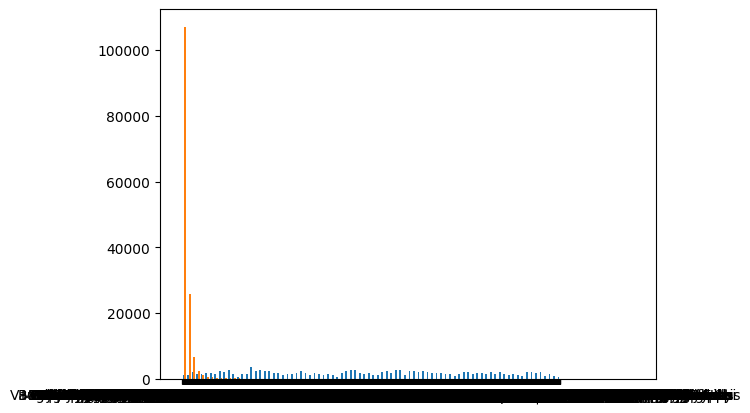

None
count    145879.000000
mean         33.949239
std          50.571682
min          11.000000
25%          14.000000
50%          20.000000
75%          35.000000
max        3400.000000
Name: Total Patients Discharged, dtype: float64


In [379]:
#-----------------
#First glance to see the distribution of Total Patients Discharge
#-----------------
import matplotlib.pyplot as plt
import numpy as np

plt.hist(tb1[['Hospital Name', 'Total Patients Discharged']], bins=100)
         #weights = np.ones(len(tb1))/ len(tb1),
         #color='skyblue', edgecolor='black')

print(plt.show())

#-----------------
#The stats
#-----------------
from scipy import stats
print(tb1['Total Patients Discharged'].describe())

### Groupby Provider and Calculate The Sum of Total Patients Discharged

In [380]:
#-----------------
#groupby provider and calculate the mean of Total Patients Discharged
#-----------------
tb1providerservices = tb1.groupby('Hospital Name').agg({'Total Patients Discharged': 'sum'}).reset_index()
tb1providerservices.sort_values(by = 'Total Patients Discharged', ascending = False)

,Hospital Name,Total Patients Discharged
30,Adventhealth Orlando,30767
1649,New York-Presbyterian Hospital,27689
1748,Nyu Langone Hospitals,26286
1523,Methodist Hospital,22228
2135,Sarasota Memorial Hospital,16770
...,...,...
1066,Inova Specialty Hospital,11
175,Atmore Community Hospital,11
222,Banner Fort Collins Medical Center,11
2795,Westover Hills Baptist Hospital,11


###Identify and create table of outliers & Remove Them



In [381]:
#-----------------
#Find and display the outliers
#-----------------

#Identify the outliers
#-----------------
percentile25 = tb1providerservices['Total Patients Discharged'].quantile(0.25)
percentile75 = tb1providerservices['Total Patients Discharged'].quantile(0.75)
iqr = percentile75 - percentile25
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr

print('Upper Limit', upper_limit)
print('Lower Limit', lower_limit)

#Display the outliers
#-----------------
outliers_above = tb1providerservices[tb1providerservices['Total Patients Discharged'] > upper_limit]
print(outliers_above)

outliers_below = tb1providerservices[tb1providerservices['Total Patients Discharged'] <lower_limit]
print(outliers_below)

#Remove the outliers
#-----------------
outgone_tb1providerservices = tb1providerservices[tb1providerservices['Total Patients Discharged'] < upper_limit]
#outgone_tb1providerservices.shape()

Upper Limit 5479.5
Lower Limit -2884.5
                                  Hospital Name  Total Patients Discharged
1                  Abbott Northwestern Hospital                       5945
30                         Adventhealth Orlando                      30767
65    Advocate Christ Hospital & Medical Center                       6533
70           Advocate Lutheran General Hospital                       6442
83               Albany Medical Center Hospital                       5638
...                                         ...                        ...
2789    West Virginia University Hospitals, Inc                       5907
2798               White Plains Hospital Center                       6453
2812        Willis Knighton Medical Center, Inc                       7173
2818                  Winchester Medical Center                       6960
2838                    Yale-New Haven Hospital                       9784

[195 rows x 2 columns]
Empty DataFrame
Columns: [Hospital Na

###Compare the Distribution of Original Data vs Data With Outliers Trimmed

/tmp/ipykernel_17271/2078761017.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(tb1providerservices['Total Patients Discharged'])
/tmp/ipykernel_17271/2078761017.py:13: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(outgone_tb1providerservices['Total Patients Discharged'])


Before Outliers Trimmed        Total Patients Discharged
count                2845.000000
mean                 1740.766608
std                  2349.418697
min                    11.000000
25%                   252.000000
50%                   872.000000
75%                  2343.000000
max                 30767.000000
After Outliers Trimmed        Total Patients Discharged
count                2650.000000
mean                 1267.906792
std                  1322.338413
min                    11.000000
25%                   228.000000
50%                   771.000000
75%                  1871.000000
max                  5426.000000


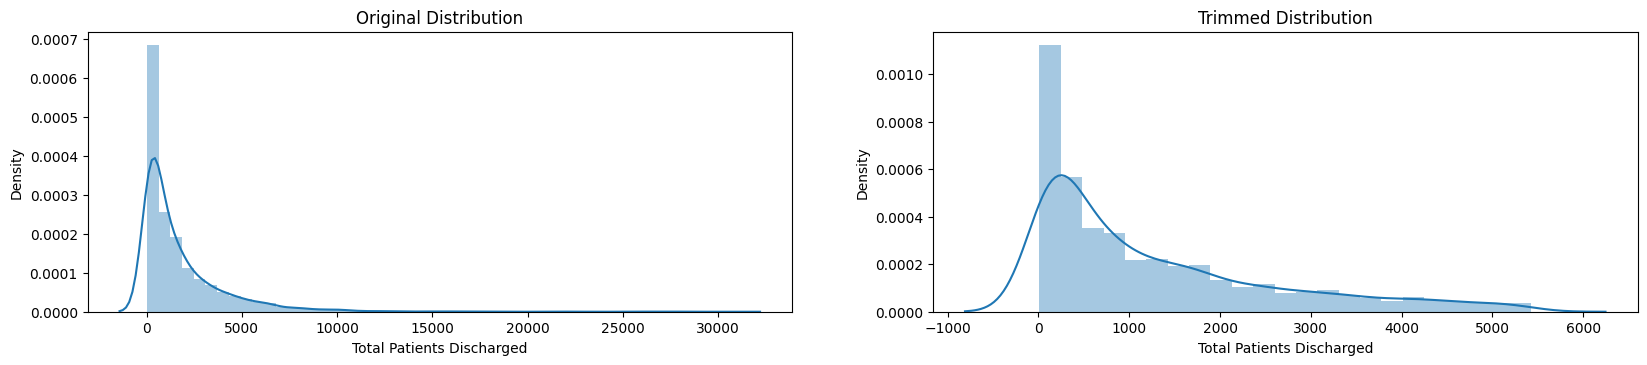

In [382]:
#-----------------
#Display the histogram by mean of Total Patients Discharged (BEFORE & AFTER triming outliers)
#-----------------

import seaborn as sns
plt.figure(figsize=(20,8))

plt.subplot(2,2,1)
sns.distplot(tb1providerservices['Total Patients Discharged'])
plt.title('Original Distribution')

plt.subplot(2,2,2)
sns.distplot(outgone_tb1providerservices['Total Patients Discharged'])
plt.title('Trimmed Distribution')

print('Before Outliers Trimmed',tb1providerservices.describe())
print('After Outliers Trimmed', outgone_tb1providerservices.describe())

#Part 3B. Medicaid Database (JSON) Reshaping Data & Integration


---

###Identify and create table of outliers & Remove Them

In [383]:
#-----------------
#Medicaid table with just the hosptial name and total discharges
#-----------------
medicaid_summary = medicaid_hospitals[['Hospital Name','Total Discharges (V + XVIII + XIX + Unknown)'] ]
medicaid_summary.head(5)

,Hospital Name,Total Discharges (V + XVIII + XIX + Unknown)
0,PIONEER HLTH SERV OF STOKES CNTY,52.0
2,COMMONWEALTH HEALTH CENTER,4403.0
3,FAIRFIELD MEMORIAL HOSPITAL,75.0
4,ROANE GENERAL HOSPITAL,190.0
5,CHOWAN HOSPITAL INC.,1389.0


In [384]:
#-----------------
#Find and display the outliers
#-----------------

#-----------------
#Identify the outliers
#-----------------
percentile25 = medicaid_summary['Total Discharges (V + XVIII + XIX + Unknown)'].quantile(0.25)
percentile75 = medicaid_summary['Total Discharges (V + XVIII + XIX + Unknown)'].quantile(0.75)
iqr = percentile75 - percentile25
upper_limit_medicaid = percentile75 + 1.5 * iqr
lower_limit_medicaid = percentile25 - 1.5 * iqr

print('Upper Limit', upper_limit_medicaid)
print('Lower Limit', lower_limit_medicaid)

#Display the outliers
#-----------------
outliers_above_medicaid =medicaid_summary[medicaid_summary['Total Discharges (V + XVIII + XIX + Unknown)'] > upper_limit]
#print(outliers_above_medicaid)

outliers_below_medicaid = medicaid_summary[medicaid_summary['Total Discharges (V + XVIII + XIX + Unknown)'] <lower_limit]
#print(outliers_below_medicaid)

#Remove the outliers
#-----------------
outgone_medicaid_hospitals = medicaid_summary[medicaid_summary['Total Discharges (V + XVIII + XIX + Unknown)'] < upper_limit]
outgone_medicaid_hospitals.nlargest(5,'Total Discharges (V + XVIII + XIX + Unknown)')




Upper Limit 2964.75
Lower Limit -1487.25


,Hospital Name,Total Discharges (V + XVIII + XIX + Unknown)
913,AURORA LAS ENCINAS BHS,5470.0
431,WEST OAKS HOSPITAL,5456.0
830,AURORA PSYCHIATRIC HOSPITAL,5439.0
116,AURORA CHICAGO LAKESHORE,5323.0
141,LAURELWOOD HOSPITAL,5298.0


###Compare the Distribution of Original Data vs Data With Outliers Trimmed

Before Outliers Trimmed        Total Discharges (V + XVIII + XIX + Unknown)
count                                    930.000000
mean                                    1310.583871
std                                     2546.779596
min                                        1.000000
25%                                      182.250000
50%                                      454.000000
75%                                     1295.250000
max                                    33343.000000


/tmp/ipykernel_17271/2155266090.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(medicaid_summary['Total Discharges (V + XVIII + XIX + Unknown)'])
/tmp/ipykernel_17271/2155266090.py:13: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(outgone_medicaid_hospitals['Total Discharges (V + XVIII + XIX

After Outliers Trimmed        Total Discharges (V + XVIII + XIX + Unknown)
count                                    894.000000
mean                                     924.253915
std                                     1184.597411
min                                        1.000000
25%                                      168.000000
50%                                      418.000000
75%                                     1134.750000
max                                     5470.000000


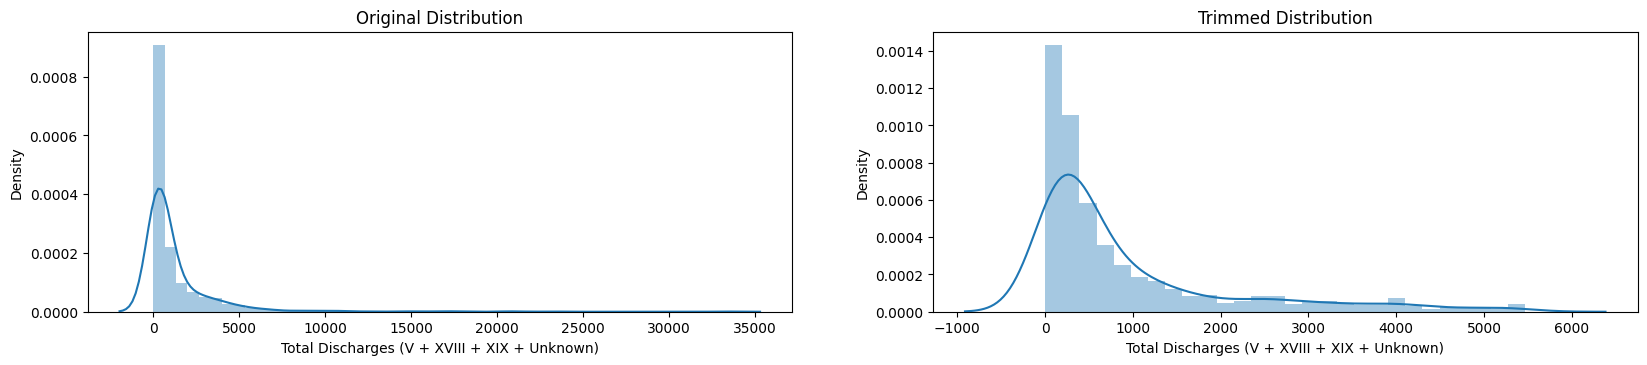

In [385]:
#-----------------
#Display the histogram by mean of Total Patients Discharged (BEFORE & AFTER triming outliers)
#-----------------

import seaborn as sns
plt.figure(figsize=(20,8))

plt.subplot(2,2,1)
sns.distplot(medicaid_summary['Total Discharges (V + XVIII + XIX + Unknown)'])
plt.title('Original Distribution')

plt.subplot(2,2,2)
sns.distplot(outgone_medicaid_hospitals['Total Discharges (V + XVIII + XIX + Unknown)'])
plt.title('Trimmed Distribution')

print('Before Outliers Trimmed',medicaid_summary.describe())
print('After Outliers Trimmed', outgone_medicaid_hospitals.describe())

###Display the distrbution of Avg Pay by Medicare

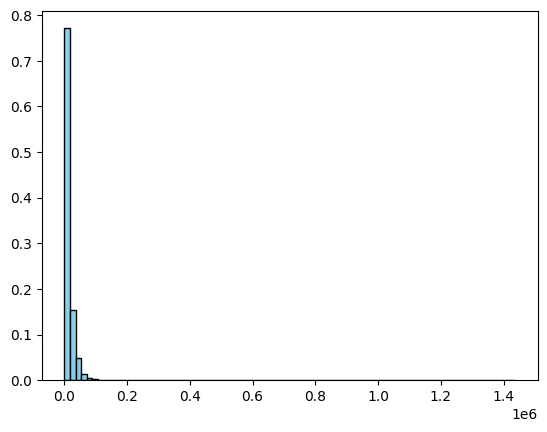

None
count    1.458790e+05
mean     1.578265e+04
std      1.966287e+04
min      3.868000e+02
25%      7.078129e+03
50%      1.085070e+04
75%      1.725262e+04
max      1.436668e+06
Name: Avg Paid by Medicare, dtype: float64


In [386]:
#-----------------
#Display the distrbution of Avg Pay by Medicare
#-----------------
plt.hist(tb1['Avg Paid by Medicare'], bins=80,
         weights = np.ones(len(tb1))/ len(tb1),
         color='skyblue', edgecolor='black')

print(plt.show())
print(tb1['Avg Paid by Medicare'].describe())

In [387]:
hospital_financials.columns

#Hospital Total Discharges (V + XVIII + XIX + Unknown) For Adults & Peds

Index(['rpt_rec_num', 'Provider CCN', 'Hospital Name', 'Street Address',
       'City', 'State Code', 'Zip Code', 'County', 'Medicare CBSA Number',
       'Rural Versus Urban',
       ...
       'Net Income from Service to Patients', 'Total Other Income',
       'Total Income', 'Total Other Expenses', 'Net Income',
       'Cost To Charge Ratio', 'Net Revenue from Medicaid', 'Medicaid Charges',
       'Net Revenue from Stand-Alone CHIP', 'Stand-Alone CHIP Charges'],
      dtype='object', length=117)

In [388]:
tb1.dtypes

,0
Hospital Name,object
City,object
Street,object
Zip Code,int64
State,object
RUCA Classification,object
Diagnosis Description,object
Total Patients Discharged,int64
Avg Medicare Services Billed,float64
Avg Total Payment,float64


In [389]:
filename2 = 'medicare_providers_discharge.csv'
tb1providerservices.to_csv(filename2, index = False)

#Part 3C. Combine Medicare and Medicaid Hospital Databases

In [390]:
#-----------------
#Medicare Hospital Database
#-----------------
medicare_hospitals = tb1.groupby('Hospital Name').agg({
    'Total Patients Discharged': 'sum',
   #Keep the first categorical value found in the provider row
   'City': 'first',
   'State': 'first',
   'Street': 'first',
   'Zip Code': 'first',
   'Ins Accepted': 'first'
 }).reset_index()
medicare_hospitals.sort_values(by = 'Total Patients Discharged', ascending = False)

,Hospital Name,Total Patients Discharged,City,State,Street,Zip Code,Ins Accepted
30,Adventhealth Orlando,30767,Orlando,FL,601 E Rollins St,32803,Medicare
1649,New York-Presbyterian Hospital,27689,New York,NY,525 East 68th Street,10065,Medicare
1748,Nyu Langone Hospitals,26286,New York,NY,550 First Avenue,10016,Medicare
1523,Methodist Hospital,22228,Omaha,NE,8303 Dodge St,68114,Medicare
2135,Sarasota Memorial Hospital,16770,Sarasota,FL,1700 S Tamiami Trl,34239,Medicare
...,...,...,...,...,...,...,...
1066,Inova Specialty Hospital,11,Alexandria,VA,"2501 Parkers Lane, 4th Floor",22306,Medicare
175,Atmore Community Hospital,11,Atmore,AL,401 Medical Park Drive,36502,Medicare
222,Banner Fort Collins Medical Center,11,Fort Collins,CO,4700 Lady Moon Dr,80528,Medicare
2795,Westover Hills Baptist Hospital,11,San Antonio,TX,3011 W Loop 1604 N,78251,Medicare


In [391]:
#-----------------
#Medicaid Hospital Database
#-----------------
medicaid_hospitals.rename(columns = {
    'Total Discharges (V + XVIII + XIX + Unknown)': 'Total Patients Discharged',
    'Street Address': 'Street',
    'State Code': 'State'}, inplace = True)
medicaid_hospitals

/tmp/ipykernel_17271/400681566.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  medicaid_hospitals.rename(columns = {


,Hospital Name,Total Patients Discharged,City,State,Street,Zip Code,Ins Accepted
0,PIONEER HLTH SERV OF STOKES CNTY,52.0,DANBURY,NC,1570 NC & 89 HWY,27016,Medicaid
2,COMMONWEALTH HEALTH CENTER,4403.0,SAIPAN,MP,LOWER NAVY HILL RD,96950,Medicaid
3,FAIRFIELD MEMORIAL HOSPITAL,75.0,WINSBORO,SC,102 US HWY 31 BYPASS NORTH,29180-0620,Medicaid
4,ROANE GENERAL HOSPITAL,190.0,SPENCER,WV,200 HOSPITAL DRIVE,25276-1060,Medicaid
5,CHOWAN HOSPITAL INC.,1389.0,EDENTON,NC,211 VIRGINIA AVENUE,27932,Medicaid
...,...,...,...,...,...,...,...
995,DALLAS COUNTY MEDICAL CENTER,166.0,FORDYCE,AR,201 NORTH CLIFTON,71742-,Medicaid
996,NINNESCAH VALLEY HEALTH SYSTEMS,282.0,KINGMAN,KS,750 AVENUE D WEST,67068,Medicaid
997,ST. ELIZABETH FLORENCE,10666.0,FLORENCE,KY,4900 HOUSTON ROAD,41042-4824,Medicaid
998,FORT WASHINGTON MEDICAL CENTER,1817.0,FORT WASHINGTON,MD,11711 LIVINGSTON ROAD,20744,Medicaid


In [392]:
#-----------------
#Join the two databases
#-----------------
all_hospitals = pd.concat([medicaid_hospitals, medicare_hospitals], axis = 0, ignore_index = True)
all_hospitals.head(5)

,Hospital Name,Total Patients Discharged,City,State,Street,Zip Code,Ins Accepted
0,PIONEER HLTH SERV OF STOKES CNTY,52.0,DANBURY,NC,1570 NC & 89 HWY,27016,Medicaid
1,COMMONWEALTH HEALTH CENTER,4403.0,SAIPAN,MP,LOWER NAVY HILL RD,96950,Medicaid
2,FAIRFIELD MEMORIAL HOSPITAL,75.0,WINSBORO,SC,102 US HWY 31 BYPASS NORTH,29180-0620,Medicaid
3,ROANE GENERAL HOSPITAL,190.0,SPENCER,WV,200 HOSPITAL DRIVE,25276-1060,Medicaid
4,CHOWAN HOSPITAL INC.,1389.0,EDENTON,NC,211 VIRGINIA AVENUE,27932,Medicaid


In [393]:
#-----------------
#Verify that the two tables were joined correctly
#-----------------
ins_accepted_counts = all_hospitals.groupby('Ins Accepted')['Ins Accepted'].value_counts().reset_index()
print(ins_accepted_counts)

  Ins Accepted  count
0     Medicaid    930
1     Medicare   2845


#Part 4. Visualization and Summarizations

##1. Comparing each state's number of medicaid and medicare hospitals

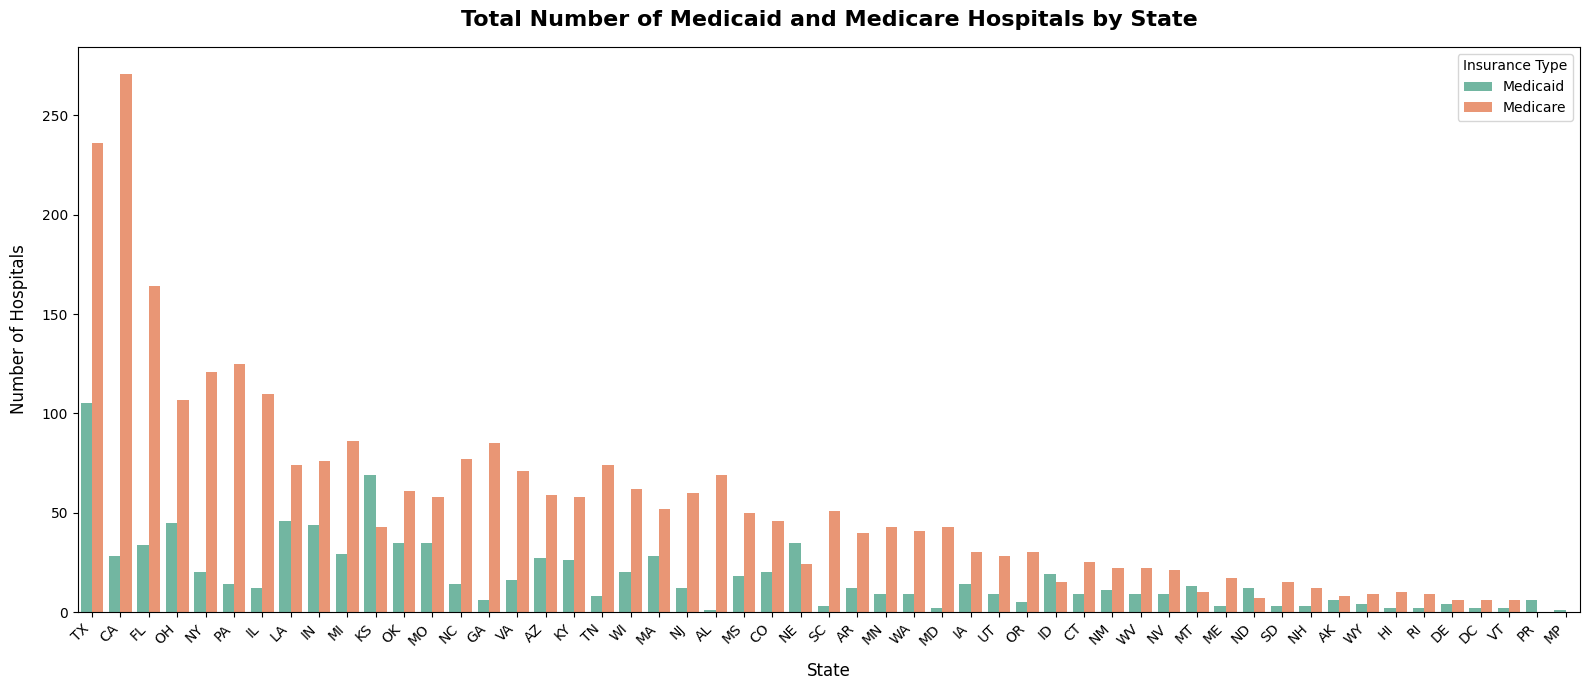

In [394]:
#1. Calculate the counts for each State and Insurance Type
state_ins_counts = all_hospitals.groupby(['State', 'Ins Accepted']).size().reset_index(name='Hospital_Count')

#2. Sort the states by most hospitals
state_totals = state_ins_counts.groupby('State')['Hospital_Count'].sum().sort_values(ascending=False)
state_ins_counts['State'] = pd.Categorical(state_ins_counts['State'], categories=state_totals.index, ordered=True)
state_ins_counts = state_ins_counts.sort_values('State')

#3. Initialize the plot canvas
plt.figure(figsize=(16, 7))

#4. Generate the side-by-side bar chart using 'hue'
sns.barplot(
    x='State',
    y='Hospital_Count',
    hue='Ins Accepted', # This makes side by side bars
    data=state_ins_counts,
    palette='Set2'       #Clean color scheme for comparison
)

#5. Adjust the labels
plt.title('Total Number of Medicaid and Medicare Hospitals by State', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('State', fontsize=12, labelpad=10)
plt.ylabel('Number of Hospitals', fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha='right') # Angles text and aligns it neatly to the tick marks
plt.legend(title='Insurance Type', loc='upper right')
plt.tight_layout()

#6. Render plot
plt.show()




##2. Which states have the most medicaid hospitals:?

/tmp/ipykernel_17271/2376210908.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


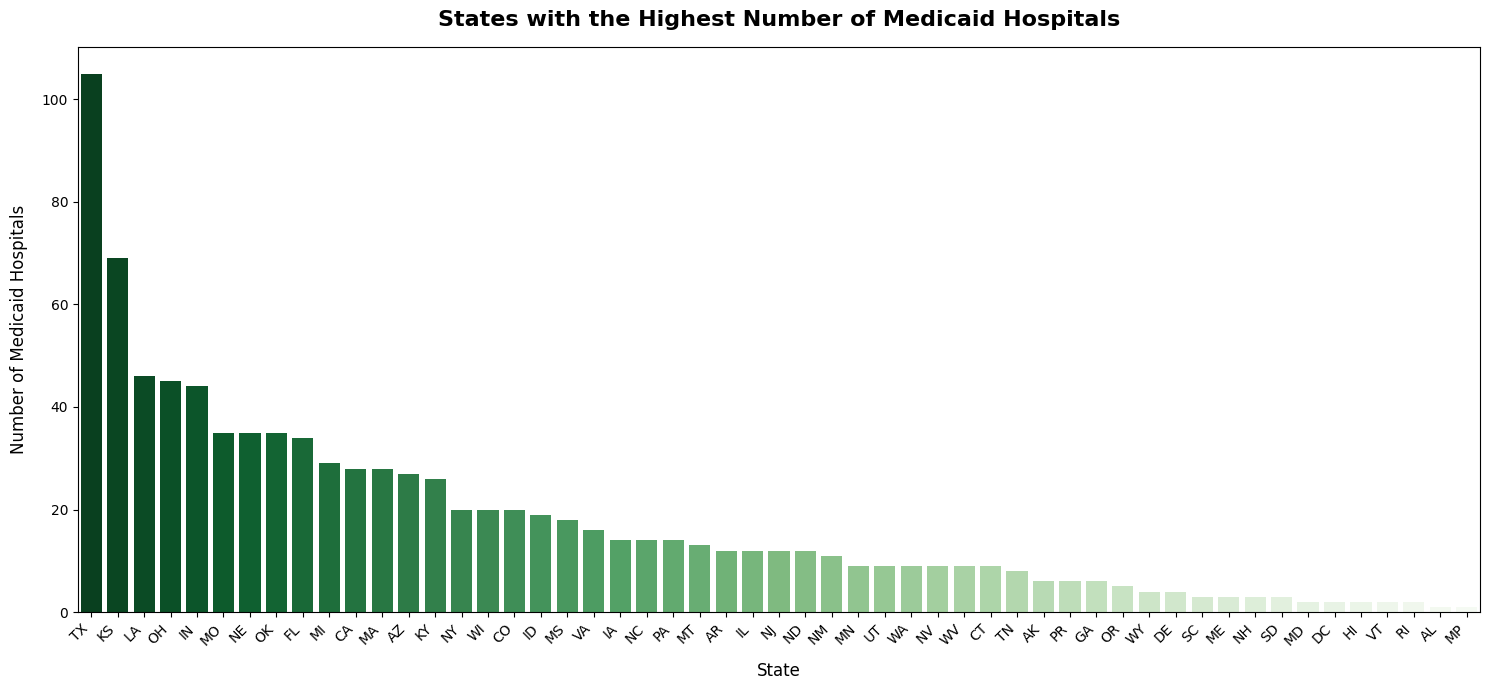

In [395]:
#1. Filter for Medicaid hospitals only
medicaid_only = all_hospitals[all_hospitals['Ins Accepted'] == 'Medicaid']

#2. Group by State and count the hospitals
state_counts = medicaid_only.groupby('State').size().reset_index(name='Medicaid_Hospital_Count')

#3. Sort the states by the highest counts
state_counts = state_counts.sort_values(by='Medicaid_Hospital_Count', ascending=False)

#4. Initialize a clean plot canvas
plt.figure(figsize=(15, 7))

#5. Create the bar chart
sns.barplot(
    x='State',
    y='Medicaid_Hospital_Count',
    data=state_counts,
    palette='Greens_r'  # Gradient color palette (darker bars for higher counts)
)

#6. Format labels and titles
plt.title('States with the Highest Number of Medicaid Hospitals', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('State', fontsize=12, labelpad=10)
plt.ylabel('Number of Medicaid Hospitals', fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha='right')  # Clean alignment for state abbreviations
plt.tight_layout()

#7. Show the chart
plt.show()


##3. Which states have the most medicare hospitals:?

/tmp/ipykernel_17271/1195331769.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


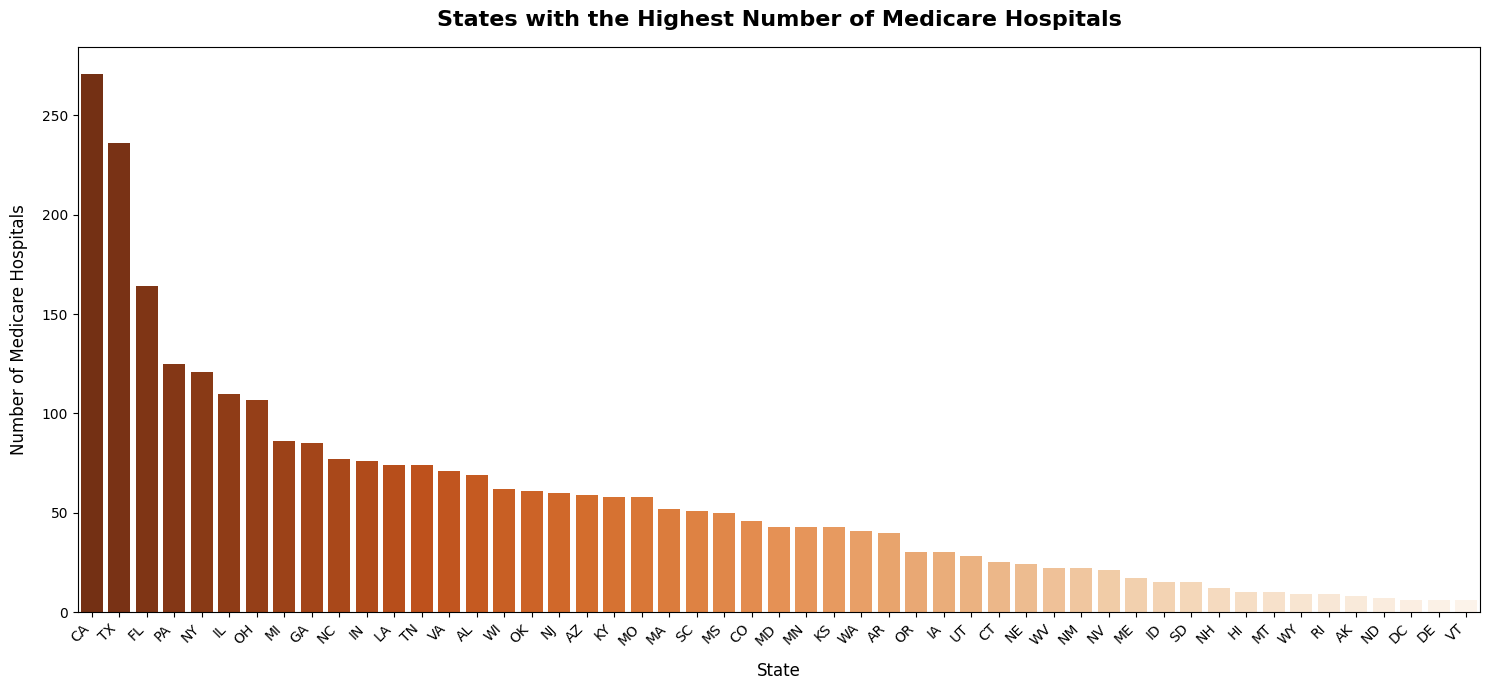

In [396]:
#1. Filter for Medicaid hospitals only
medicareonly = all_hospitals[all_hospitals['Ins Accepted'] == 'Medicare']

#2. Group by State and count the hospitals
state_counts = medicareonly.groupby('State').size().reset_index(name='Medicare_Hospital_Count')

#3. Sort the states by  highest counts
state_counts = state_counts.sort_values(by='Medicare_Hospital_Count', ascending=False)

#4. Initialize a clean plot canvas
plt.figure(figsize=(15, 7))

#5. Create the bar chart
sns.barplot(
    x='State',
    y='Medicare_Hospital_Count',
    data=state_counts,
    palette='Oranges_r'  # Gradient color palette (darker bars for higher counts)
)

#6. Format labels and titles
plt.title('States with the Highest Number of Medicare Hospitals', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('State', fontsize=12, labelpad=10)
plt.ylabel('Number of Medicare Hospitals', fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha='right')  # Clean alignment for state abbreviations
plt.tight_layout()

#7. Show the chart
plt.show()

##4. States with the most discharged patients

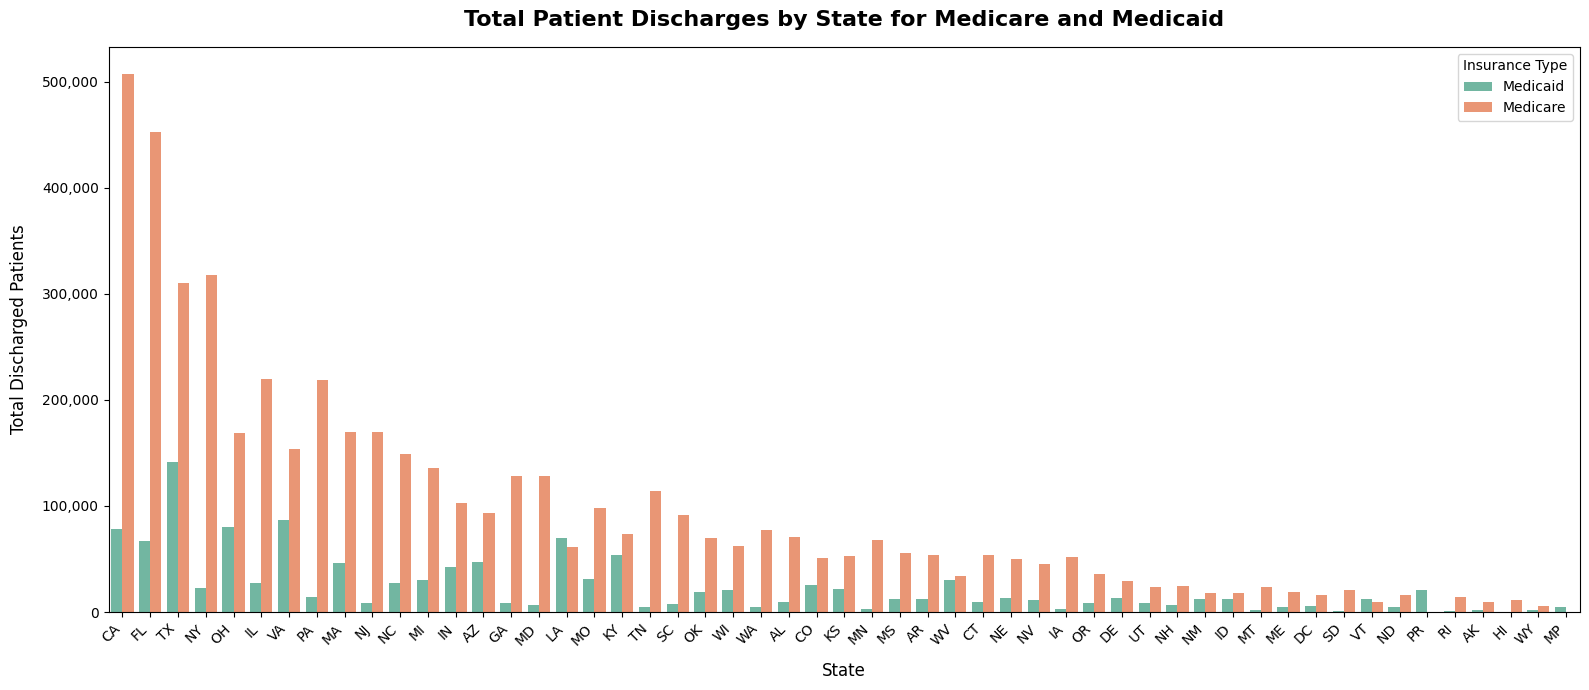

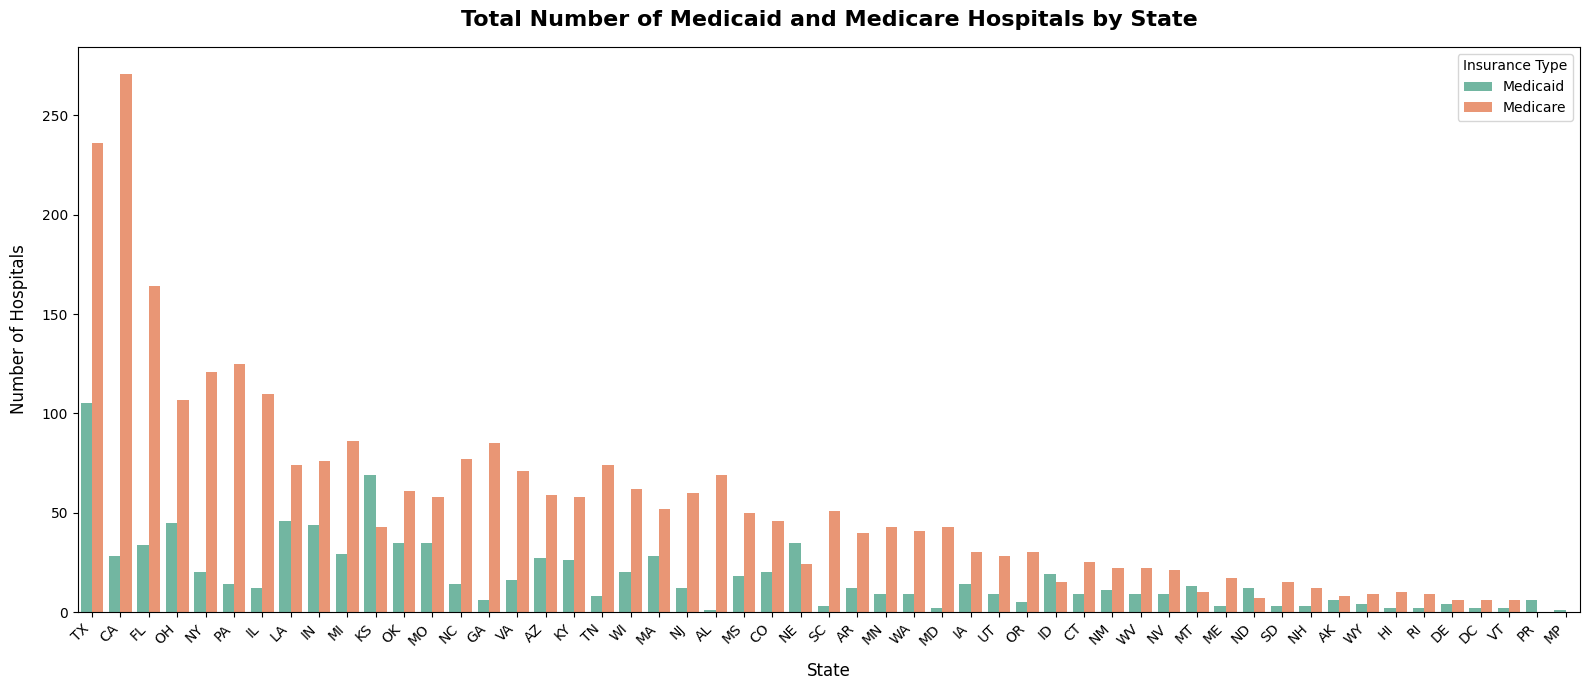

In [397]:

#1. Calculate the TOTAL PATIENTS DISCHARGED for each State and Insurance Type
state_ins_discharges = all_hospitals.groupby(['State', 'Ins Accepted'])['Total Patients Discharged'].sum().reset_index(name='Total Patients Discharged')

#2. Sort the data with the highest # discharge patients
state_totals = state_ins_discharges.groupby('State')['Total Patients Discharged'].sum().sort_values(ascending=False)
state_ins_discharges['State'] = pd.Categorical(state_ins_discharges['State'], categories=state_totals.index, ordered=True)
state_ins_discharges = state_ins_discharges.sort_values('State')

#3. Initialize the plot canvas
plt.figure(figsize=(16, 7))

#4. Generate the side-by-side bar chart using 'hue'
sns.barplot(
    x='State',
    y='Total Patients Discharged', # Swapped out hospital counts for numeric patient volumes
    hue='Ins Accepted',
    data=state_ins_discharges,
    palette='Set2'
)

#5. Addjust the labels Y-axis
plt.title('Total Patient Discharges by State for Medicare and Medicaid', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('State', fontsize=12, labelpad=10)
plt.ylabel('Total Discharged Patients', fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Insurance Type', loc='upper right')

#6. Formats Y-axis labels with commas
plt.gca().get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.tight_layout()

#7. Show Plot
plt.show()

##-----------------
#Compare total discharges to total hospitals
#-----------------

#1. Calculate the counts for each State and Insurance Type
state_ins_counts = all_hospitals.groupby(['State', 'Ins Accepted']).size().reset_index(name='Hospital_Count')

#2. Sort the states by most hospitals
state_totals = state_ins_counts.groupby('State')['Hospital_Count'].sum().sort_values(ascending=False)
state_ins_counts['State'] = pd.Categorical(state_ins_counts['State'], categories=state_totals.index, ordered=True)
state_ins_counts = state_ins_counts.sort_values('State')

#3. Initialize the plot canvas
plt.figure(figsize=(16, 7))

#4. Generate the side-by-side bar chart using 'hue'
sns.barplot(
    x='State',
    y='Hospital_Count',
    hue='Ins Accepted', # This makes side by side bars
    data=state_ins_counts,
    palette='Set2'       #Clean color scheme for comparison
)

#5. Adjust the labels
plt.title('Total Number of Medicaid and Medicare Hospitals by State', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('State', fontsize=12, labelpad=10)
plt.ylabel('Number of Hospitals', fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha='right') # Angles text and aligns it neatly to the tick marks
plt.legend(title='Insurance Type', loc='upper right')
plt.tight_layout()

#6. Render plot
plt.show()


